In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from textblob import TextBlob

from sklearn.feature_extraction.text import (
    TfidfVectorizer
)

from sklearn.model_selection import (
    train_test_split
)

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

from sklearn.preprocessing import LabelEncoder

from sklearn.cluster import KMeans

from wordcloud import WordCloud

sns.set_style("whitegrid")

plt.rcParams["figure.figsize"] = (10,5)


In [2]:
df = pd.read_csv(
    "reviews_complaints_dataset.csv"
)


In [3]:
print("=" * 60)
print("NLP DATASET OVERVIEW")
print("=" * 60)

print("\nShape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nFirst 5 Rows:")
print(df.head())

print("\nMissing Values:")
print(df.isnull().sum())



NLP DATASET OVERVIEW

Shape:
(5000, 10)

Columns:
Index(['review_id', 'user_id', 'feature_name', 'review_text', 'rating',
       'sentiment', 'issue_category', 'support_ticket_flag', 'app_version',
       'timestamp'],
      dtype='object')

First 5 Rows:
  review_id  user_id feature_name  \
0   R000001  U007305  Watch Party   
1   R000002  U001912  Watch Party   
2   R000003  U008233  Watch Party   
3   R000004  U007119  Watch Party   
4   R000005  U003463  Watch Party   

                                         review_text  rating sentiment  \
0  Room creation fails half the time. Very frustr...     1.0  negative   
1  Watch party worked flawlessly. Great concept, ...     5.0  positive   
2  Room creation fails half the time. Very frustr...     1.0  negative   
3   Had to retry 3 times before the session started.     2.0  negative   
4  Watch party is okay but could use better frien...     3.0   neutral   

        issue_category  support_ticket_flag app_version            timestamp

# SENTIMENT DISTRIBUTION

In [4]:
print("=" * 60)
print("SENTIMENT DISTRIBUTION")
print("=" * 60)

sentiment_distribution = (

    df["sentiment"]
    .value_counts()

)

print(sentiment_distribution)

SENTIMENT DISTRIBUTION
sentiment
negative    2061
positive    1954
neutral      985
Name: count, dtype: int64


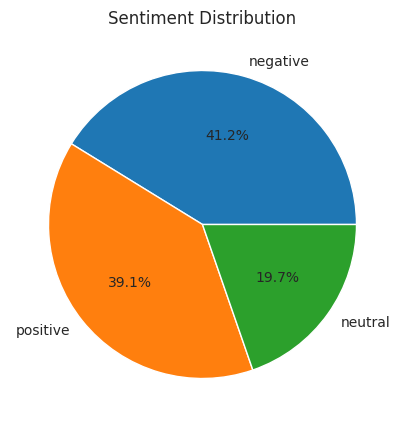

In [5]:
plt.figure(figsize=(8,5))

plt.pie(
    sentiment_distribution,
    labels=sentiment_distribution.index,
    autopct="%1.1f%%"
)

plt.title(
    "Sentiment Distribution"
)

plt.show()

# FEATURE-WISE NEGATIVE REVIEWS

In [28]:
negative_reviews = df[
    df["sentiment"] == "negative"
]

negative_feature_analysis = (

    negative_reviews[
        "feature_name"
    ]
    .value_counts()

)

print("\nNegative Reviews by Feature:")
print(negative_feature_analysis)


Negative Reviews by Feature:
feature_name
Watch Party           753
Mini Preview Clips    672
AI Recommendations    408
Watchlist             138
Downloads              90
Name: count, dtype: int64


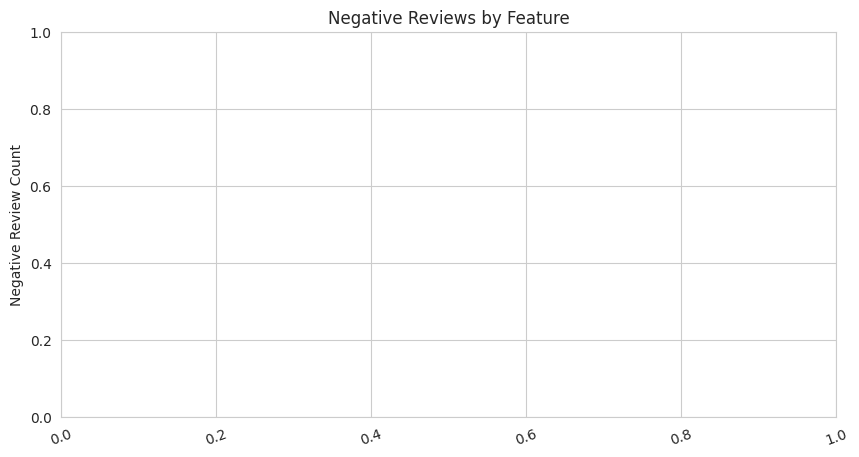

In [7]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=negative_feature_analysis.index,
    y=negative_feature_analysis.values,
    palette="Reds_r"
)

plt.title(
    "Negative Reviews by Feature"
)

plt.ylabel("Negative Review Count")

plt.xticks(rotation=20)

plt.show()



# ISSUE CATEGORY ANALYSIS

In [8]:
print("=" * 60)
print("ISSUE CATEGORY ANALYSIS")
print("=" * 60)

issue_analysis = (

    df["issue_category"]
    .value_counts()

)

print(issue_analysis)

ISSUE CATEGORY ANALYSIS
issue_category
Positive Experience       1821
Recommendation Quality     719
Useless Feature            686
Bug                        551
Confusing UI               459
Crashes                    283
Performance                252
Too Many Steps             179
Slow Loading                50
Name: count, dtype: int64


/tmp/ipykernel_2238/2932654589.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


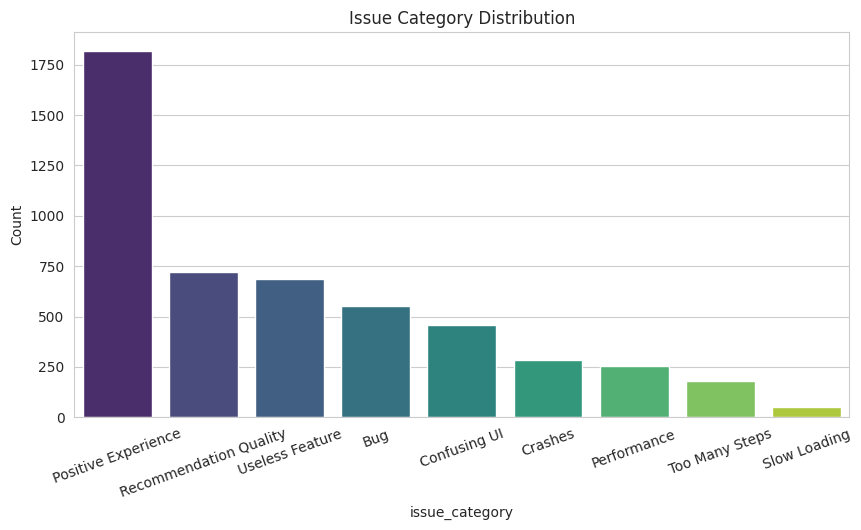

In [9]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=issue_analysis.index,
    y=issue_analysis.values,
    palette="viridis"
)

plt.title(
    "Issue Category Distribution"
)

plt.ylabel("Count")

plt.xticks(rotation=20)

plt.show()

# TEXTBLOB SENTIMENT SCORING

In [10]:
df["polarity"] = df[
    "review_text"
].apply(

    lambda x:
    TextBlob(x).sentiment.polarity

)

print("\nSample Polarity Scores:")
print(

    df[
        ["review_text", "polarity"]
    ].head()

)



Sample Polarity Scores:
                                         review_text  polarity
0  Room creation fails half the time. Very frustr... -0.395556
1  Watch party worked flawlessly. Great concept, ...  1.000000
2  Room creation fails half the time. Very frustr... -0.395556
3   Had to retry 3 times before the session started.  0.000000
4  Watch party is okay but could use better frien...  0.500000


# SENTIMENT POLARITY DISTRIBUTION

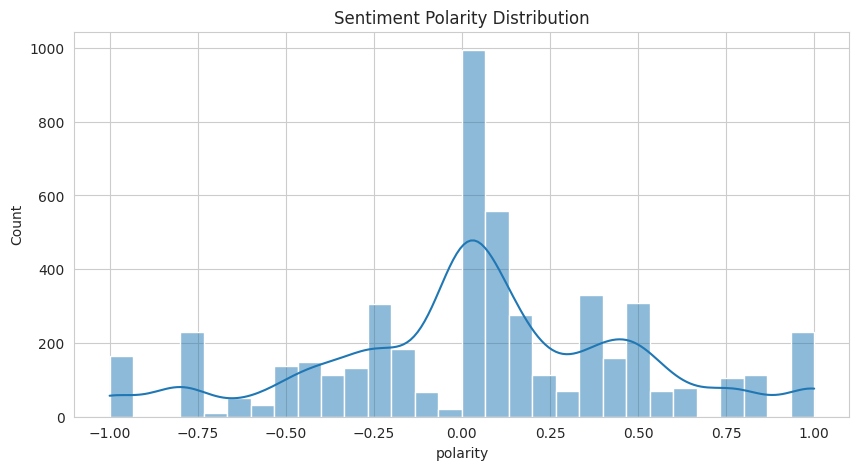

In [11]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["polarity"],
    bins=30,
    kde=True
)

plt.title(
    "Sentiment Polarity Distribution"
)

plt.show()

# WORD CLOUD

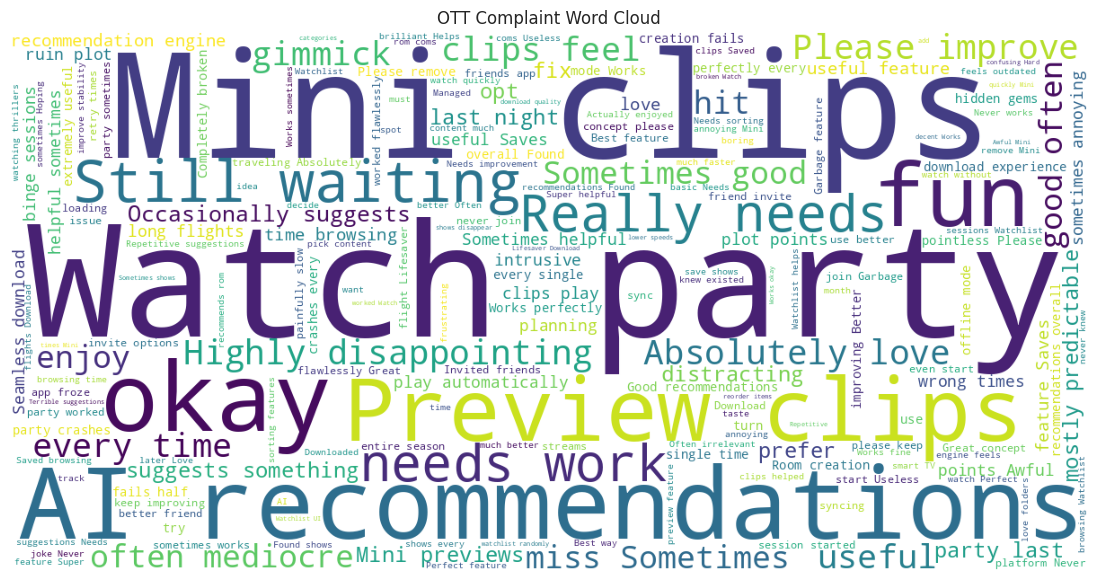

In [12]:
all_reviews = " ".join(
    df["review_text"]
)

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(all_reviews)

plt.figure(figsize=(14,7))

plt.imshow(wordcloud)

plt.axis("off")

plt.title(
    "OTT Complaint Word Cloud"
)

plt.show()

# TF-IDF VECTORIZATION

In [13]:
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=1000
)

X = tfidf.fit_transform(
    df["review_text"]
)

print("\nTF-IDF Matrix Shape:")
print(X.shape)


TF-IDF Matrix Shape:
(5000, 202)


# IMP NLP KEYWORD

In [14]:
keywords = tfidf.get_feature_names_out()

print("\nTop Keywords:")
print(keywords[:50])


Top Keywords:
['10' '50' 'absolutely' 'actually' 'add' 'ai' 'annoying' 'app'
 'automatically' 'awful' 'basic' 'best' 'better' 'binge' 'boring'
 'brilliant' 'broken' 'browsing' 'categories' 'clips' 'completely' 'coms'
 'concept' 'confusing' 'content' 'couldn' 'crashes' 'creation' 'decent'
 'decide' 'disappear' 'disappeared' 'disappointing' 'distracting'
 'download' 'downloaded' 'downloads' 'engine' 'enjoy' 'enjoyed' 'entire'
 'error' 'existed' 'expected' 'experience' 'expired' 'extremely' 'fail'
 'failing' 'fails']


# COMPLAINT CLASSIFICATION MODEL

In [15]:
print("=" * 60)
print("COMPLAINT CLASSIFICATION")
print("=" * 60)

encoder = LabelEncoder()

y = encoder.fit_transform(
    df["issue_category"]
)

COMPLAINT CLASSIFICATION


# TRAIN- TEST SPLIT

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [17]:
model = LogisticRegression()

model.fit(
    X_train,
    y_train
)

LogisticRegression()

In [18]:
predictions = model.predict(
    X_test
)

In [19]:
print(
    classification_report(
        y_test,
        predictions
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       113
           1       1.00      1.00      1.00        95
           2       1.00      1.00      1.00        67
           3       1.00      1.00      1.00        48
           4       1.00      1.00      1.00       359
           5       1.00      1.00      1.00       132
           6       1.00      1.00      1.00         8
           7       1.00      1.00      1.00        45
           8       1.00      1.00      1.00       133

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



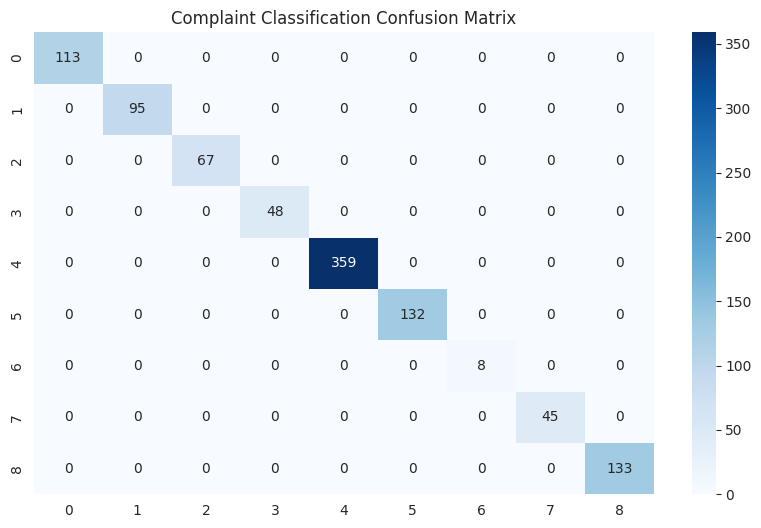

In [20]:
cm = confusion_matrix(
    y_test,
    predictions
)

plt.figure(figsize=(10,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Complaint Classification Confusion Matrix"
)

plt.show()

# COMPLAINT CLUSTERING

In [21]:
print("=" * 60)
print("COMPLAINT CLUSTERING")
print("=" * 60)

kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

clusters = kmeans.fit_predict(X)

df["complaint_cluster"] = clusters

COMPLAINT CLUSTERING


In [22]:
cluster_distribution = (

    df["complaint_cluster"]
    .value_counts()

)

print(cluster_distribution)



complaint_cluster
0    3425
2     986
1     589
Name: count, dtype: int64


/tmp/ipykernel_2238/3956826530.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


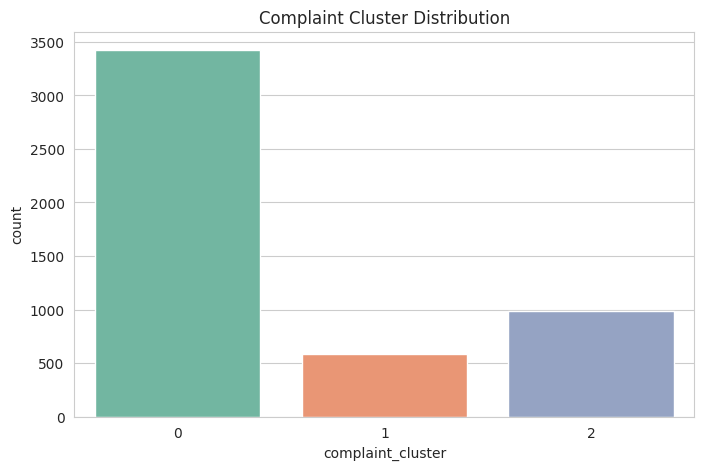

In [23]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="complaint_cluster",
    palette="Set2"
)

plt.title(
    "Complaint Cluster Distribution"
)

plt.show()

# FEATURE WISE AVG RATING

In [24]:
ratings = (

    df.groupby("feature_name")[
        "rating"
    ]
    .mean()
    .sort_values(ascending=False)

)

print("\nAverage Ratings:")
print(ratings)


Average Ratings:
feature_name
Downloads             4.175416
Watchlist             3.571637
AI Recommendations    2.961219
Mini Preview Clips    2.455782
Watch Party           2.235696
Name: rating, dtype: float64


/tmp/ipykernel_2238/682215781.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


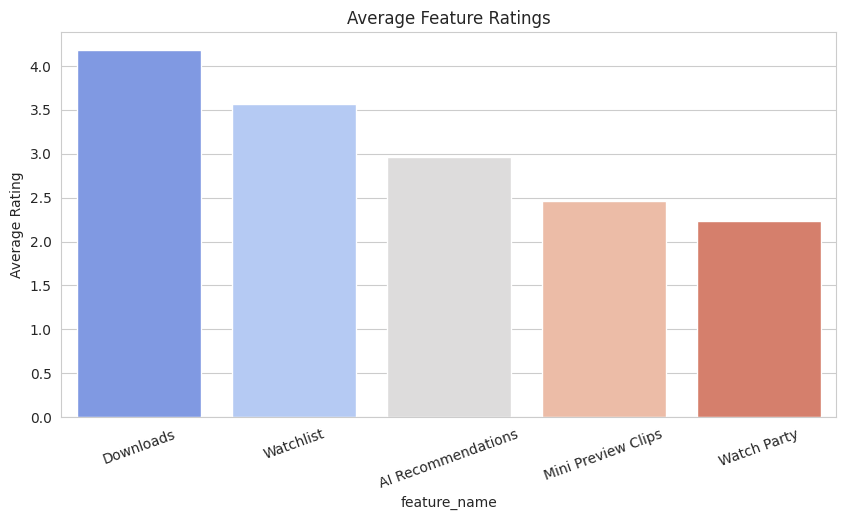

In [25]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=ratings.index,
    y=ratings.values,
    palette="coolwarm"
)

plt.title(
    "Average Feature Ratings"
)

plt.ylabel("Average Rating")

plt.xticks(rotation=20)

plt.show()


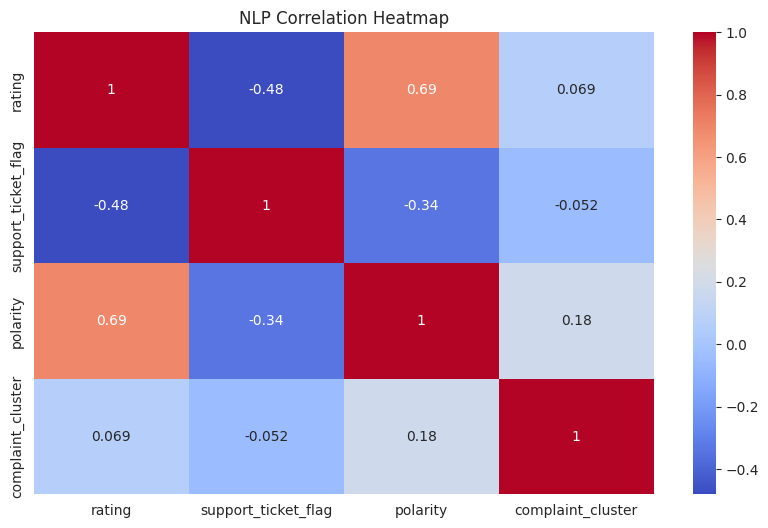

In [26]:
numerical_df = df.select_dtypes(
    include=np.number
)

corr_matrix = numerical_df.corr()

plt.figure(figsize=(10,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title(
    "NLP Correlation Heatmap"
)

plt.show()

# SENTIMENT BY FEATURE

feature_name
Mini Preview Clips   -0.208495
AI Recommendations   -0.017986
Watch Party           0.032710
Watchlist             0.320309
Downloads             0.324992
Name: polarity, dtype: float64


/tmp/ipykernel_2238/3448068492.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


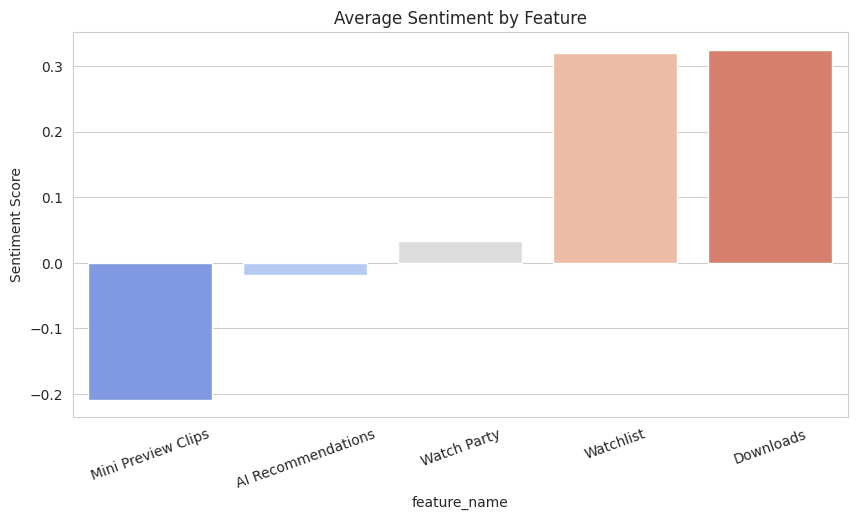

In [31]:
feature_sentiment = (

    df.groupby("feature_name")[
        "polarity"
    ]
    .mean()
    .sort_values()

)

print(feature_sentiment)

plt.figure(figsize=(10,5))

sns.barplot(
    x=feature_sentiment.index,
    y=feature_sentiment.values,
    palette="coolwarm"
)

plt.title(
    "Average Sentiment by Feature"
)

plt.ylabel("Sentiment Score")

plt.xticks(rotation=20)

plt.show()

# Support Ticket Analysis

feature_name
Watch Party           0.276667
Mini Preview Clips    0.250833
AI Recommendations    0.149091
Watchlist             0.085714
Downloads             0.042500
Name: support_ticket_flag, dtype: float64


/tmp/ipykernel_2238/2263840083.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


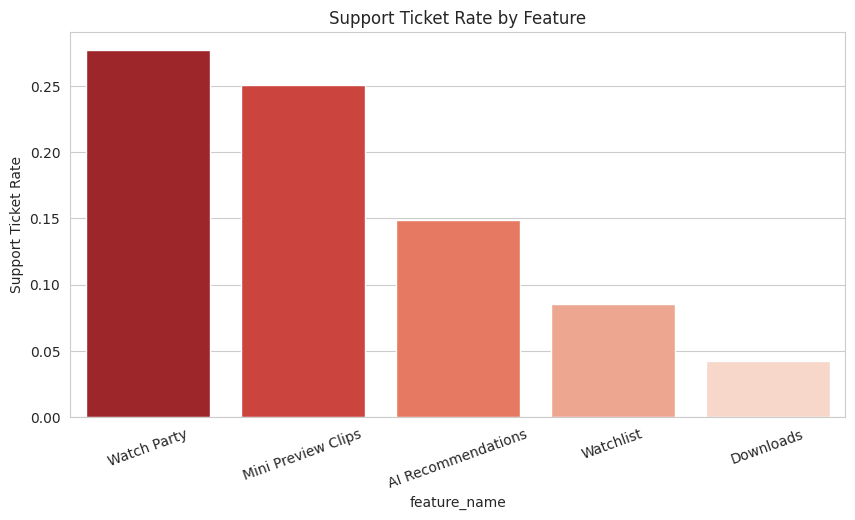

In [32]:
support_analysis = (

    df.groupby("feature_name")[
        "support_ticket_flag"
    ]
    .mean()
    .sort_values(ascending=False)

)

print(support_analysis)

plt.figure(figsize=(10,5))

sns.barplot(
    x=support_analysis.index,
    y=support_analysis.values,
    palette="Reds_r"
)

plt.title(
    "Support Ticket Rate by Feature"
)

plt.ylabel("Support Ticket Rate")

plt.xticks(rotation=20)

plt.show()

# Rating Distribution

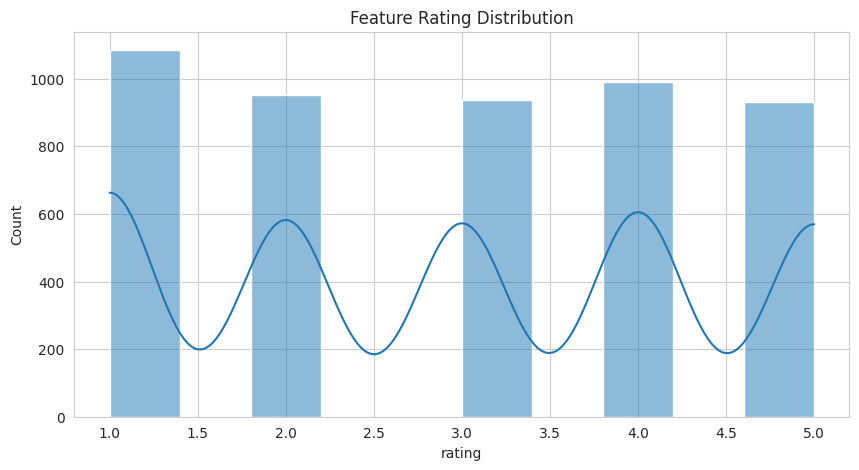

In [33]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["rating"],
    bins=10,
    kde=True
)

plt.title(
    "Feature Rating Distribution"
)

plt.show()

# Sentiment vs Rating

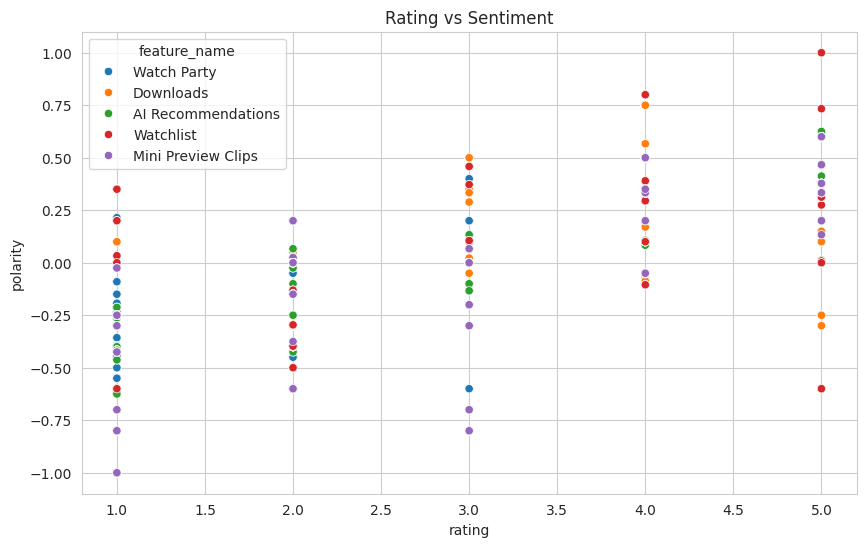

In [34]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="rating",
    y="polarity",
    hue="feature_name"
)

plt.title(
    "Rating vs Sentiment"
)

plt.show()

# Top Complaint Keywords

In [35]:
tfidf_scores = np.asarray(
    X.mean(axis=0)
).ravel()

keyword_scores = pd.DataFrame({

    "keyword": keywords,

    "score": tfidf_scores

})

top_keywords = keyword_scores.sort_values(
    by="score",
    ascending=False
).head(20)

print(top_keywords)

             keyword     score
19             clips  0.048819
107             mini  0.040855
52           feature  0.039956
193            watch  0.039780
189           useful  0.039176
178             time  0.037046
141  recommendations  0.033468
121            party  0.031799
5                 ai  0.031456
200            works  0.030431
101             love  0.030032
195        watchlist  0.029295
6           annoying  0.029066
36         downloads  0.028009
12            better  0.027970
75           helpful  0.026573
152            saves  0.024113
111            needs  0.022800
84         improving  0.021829
70              good  0.021527


# Complaint Cluster Insights

In [36]:
cluster_feature_analysis = (

    df.groupby("complaint_cluster")[
        "feature_name"
    ]
    .value_counts()

)

print(cluster_feature_analysis)

complaint_cluster  feature_name      
0                  Mini Preview Clips    1057
                   Downloads              689
                   Watchlist              586
                   AI Recommendations     550
                   Watch Party            543
1                  AI Recommendations     485
                   Watch Party            104
2                  Watch Party            553
                   Mini Preview Clips     143
                   Watchlist              114
                   Downloads              111
                   AI Recommendations      65
Name: count, dtype: int64


In [29]:
highest_complaints = (
    negative_feature_analysis.idxmax()
)

lowest_rating = (
    ratings.idxmin()
)

print("=" * 60)
print("EXECUTIVE SUMMARY")
print("=" * 60)

print(f"""
1. {highest_complaints} receives
   the highest negative sentiment.

2. {lowest_rating} has the lowest
   customer satisfaction rating.

3. Complaint clustering reveals
   recurring playback and UX issues.

4. NLP analysis successfully identifies
   customer frustration patterns.

5. Negative sentiment strongly impacts
   OTT feature perception.
""")

EXECUTIVE SUMMARY

1. Watch Party receives
   the highest negative sentiment.

2. Watch Party has the lowest
   customer satisfaction rating.

3. Complaint clustering reveals
   recurring playback and UX issues.

4. NLP analysis successfully identifies
   customer frustration patterns.

5. Negative sentiment strongly impacts
   OTT feature perception.



In [30]:
print("=" * 60)
print("PRODUCT RECOMMENDATIONS")
print("=" * 60)

print("""
1. Improve UX for complaint-heavy features.

2. Optimize playback stability
   and reduce buffering issues.

3. Improve recommendation quality.

4. Continuously monitor user sentiment
   using NLP pipelines.

5. Prioritize redesign of features
   with high negative sentiment.
""")

PRODUCT RECOMMENDATIONS

1. Improve UX for complaint-heavy features.

2. Optimize playback stability
   and reduce buffering issues.

3. Improve recommendation quality.

4. Continuously monitor user sentiment
   using NLP pipelines.

5. Prioritize redesign of features
   with high negative sentiment.



# Final NLP Insights

- Watch Party generates the highest negative sentiment.
- Playback and UX are the dominant complaint categories.
- Negative reviews strongly correlate with low ratings.
- Complaint clustering reveals recurring frustration themes.
- NLP successfully identifies feature-level dissatisfaction signals.